# Exploratory Data Analysis (EDA)
## Objective

The objective of Exploratory Data Analysis (EDA) is to understand the structure, quality, and characteristics of the cleaned supply chain dataset through statistical summaries and visualizations. This analysis aims to identify patterns, trends, relationships, and potential anomalies in sales, profitability, customers, products, and logistics. The insights obtained from EDA will support feature engineering, SQL analysis, and the development of interactive Power BI dashboards.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Data Clean Supply_Chain.csv to Data Clean Supply_Chain (1).csv


In [ ]:
df= pd.read_csv('/content/Data Clean Supply_Chain.csv')

In [ ]:
df.shape

(180519, 43)

In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Name,Product Price,Shipping_Date,Shipping Mode,Customer FullName
0,Debit,3,4,91.25,314.64,Advance Shipping,0,73,Sporting Goods,Caguas,...,91.25,Southeast Asia,Java Occidental,Completed,1360,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,Cally Holloway
1,Transfer,5,4,-249.09,311.36,Late Delivery,1,73,Sporting Goods,Caguas,...,-249.09,South Asia,Rajastán,Pending,1360,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,Irene Luna
2,Cash,4,4,-247.78,309.72,Shipping On Time,0,73,Sporting Goods,San Jose,...,-247.78,South Asia,Rajastán,Closed,1360,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,Gillian Maldonado
3,Debit,3,4,22.86,304.81,Advance Shipping,0,73,Sporting Goods,Los Angeles,...,22.86,Oceania,Queensland,Completed,1360,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,Tana Tate
4,Payment,2,4,134.21,298.25,Advance Shipping,0,73,Sporting Goods,Caguas,...,134.21,Oceania,Queensland,Pending_Payment,1360,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,Orli Hendricks


In [ ]:
cols = df.columns.tolist()

# Remove the column from its current position
cols.remove('Customer FullName')

# Find where to insert it
idx = cols.index('Customer Id')

# Insert after Customer Id
cols.insert(idx + 1, 'Customer FullName')

# Reorder the dataframe
df = df[cols]

Customer Fullname column is arranged in customer category since we combined both first and last name to full name and later placed it.

In [ ]:
df1=df.copy()

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Id                    180519 non-null  int64  
 12  Customer FullName             

In [ ]:
df1['Order_Date'] = pd.to_datetime(df1['Order_Date'])
df1['Shipping_Date'] = pd.to_datetime(df1['Shipping_Date'])

In [ ]:
df1['Customer Zipcode'] = df1['Customer Zipcode'].astype('Int64')

# Data Type Restoration

Since CSV files do not preserve data types, the date columns were converted back to the datetime format and the Customer Zipcode column was restored to the nullable integer (Int64) data type to ensure accurate analysis and enable time-based visualizations.

In [ ]:
num_cols=df1.select_dtypes(include=['int64','float64','Int64']).columns.tolist()

exclude_cols=[col for col in num_cols if 'Id' in col.title()]
exclude_cols.extend(['Latitude','Longitude'])

num_cols=[col for col in num_cols if col not in exclude_cols]

print(num_cols)

['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Customer Zipcode', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']


In [ ]:
num_cols

['Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Late_delivery_risk',
 'Customer Zipcode',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Product Price']

In [ ]:
cat_cols=df1.select_dtypes(include=['object']).columns.tolist()
cat_cols

['Type',
 'Delivery Status',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer FullName',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Department Name',
 'Market',
 'Order City',
 'Order Country',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Name',
 'Shipping Mode']

## Univariate Analysis - Numerical Variables

Analyze the distribution of numerical variables to understand their central tendency, spread, skewness, and identify any unusual patterns or potential outliers that may influence business decisions.

# Sales Distribution:

Analyze the distribution of sales values to understand customer purchasing behavior, identify common transaction amounts, and detect the presence of skewness or unusually high-value orders.

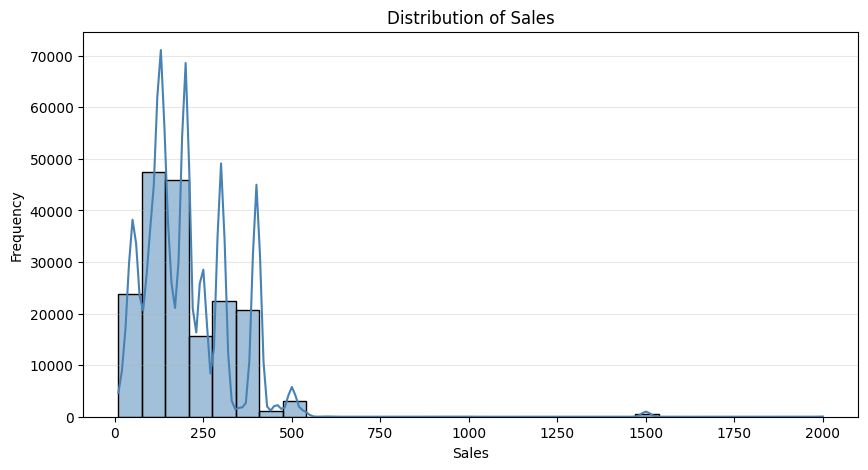

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Sales'], bins=30, kde=True,color='steelblue')

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

The sales distribution is positively skewed, with the majority of transactions concentrated between approximately $50 and $500. A small number of orders have exceptionally high sales values (around $1,500–$2,000), creating a long right tail and indicating the presence of outliers.

Business Insight

Most revenue is generated through frequent low-to-medium value transactions, while a limited number of high-value orders contribute disproportionately to total sales. These high-value transactions should be further analyzed to identify premium products, key customers, or specific markets driving significant revenue.

# Product Price Distribution:

Analyze the distribution of product prices to understand pricing patterns, identify common price ranges, and detect the presence of premium-priced products.

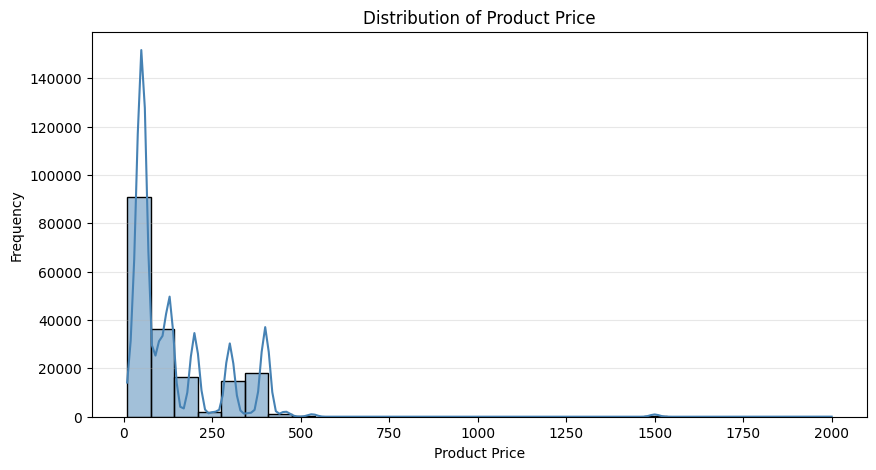

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Product Price'], bins=30, kde=True,color='steelblue')

plt.title('Distribution of Product Price')
plt.xlabel('Product Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

Observation

The product price distribution is positively skewed, with most products priced below $500.We can observe only some part of price is going 1500 which will increase the revenue more.

Business Insight

The product portfolio is primarily composed of low-to-mid priced products, while premium products represent a smaller segment. These premium items may generate higher revenue per sale and should be analyzed separately for pricing and profitability strategies

# Benefit per Order Distribution:

Analyze the distribution of benefit generated per order to evaluate overall profitability and identify profitable and loss-making transactions.

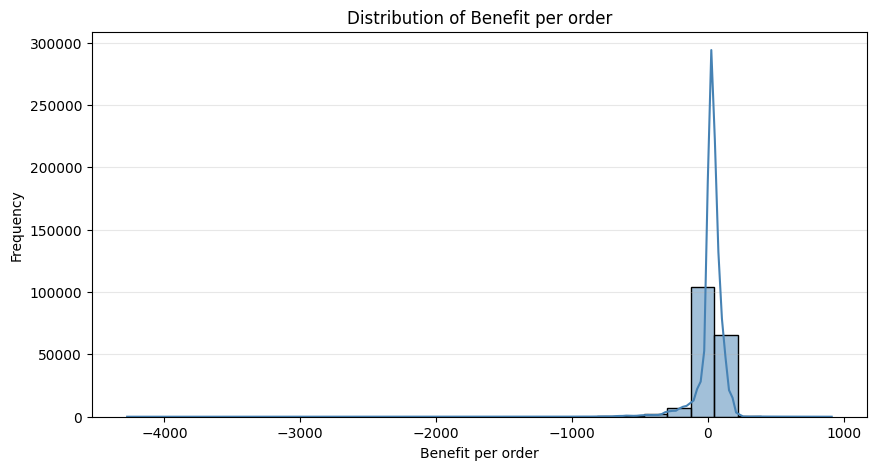

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Benefit per order'], bins=30, kde=True,color='steelblue')

plt.title('Distribution of Benefit per order')
plt.xlabel('Benefit per order')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

Observation

Most orders generate benefits close to zero or moderate positive values, while a small number of orders result in significant financial losses, creating a long left tail in the distribution.

Business Insight

Although the majority of orders are profitable, certain transactions incur substantial losses. These loss-making orders should be investigated to identify potential causes such as excessive discounts, high shipping costs, or pricing inefficiencies.

# Order Item Discount Distribution:


Examine the distribution of discounts applied to order items and understand the company's discounting practices.

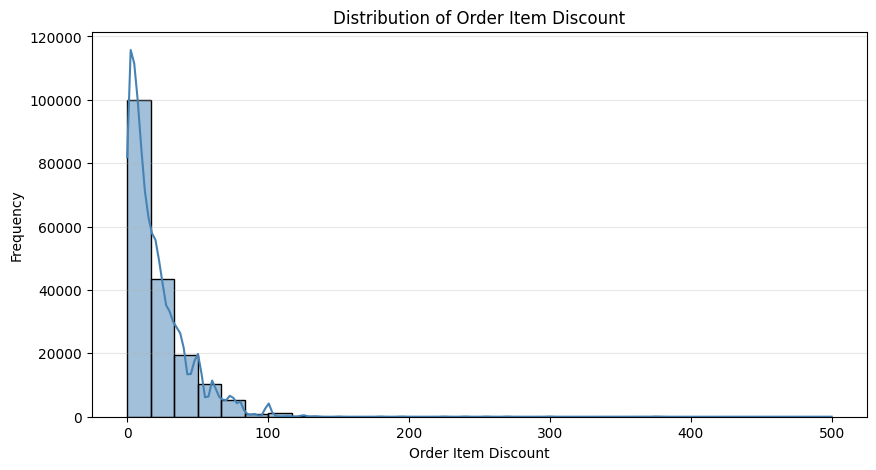

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Order Item Discount'], bins=30, kde=True,color='steelblue')

plt.title('Distribution of Order Item Discount')
plt.xlabel('Order Item Discount')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

Observation

The distribution is positively skewed, with most order items receiving relatively low discounts. Higher discount values occur infrequently, resulting in a long right tail.

Business Insight

The company follows a controlled discounting strategy, where most products are sold with minimal discounts, helping maintain profitability while occasionally offering larger promotional discounts.

# Order Item Quantity Distribution:

Analyze the quantity of products purchased per order to understand customer purchasing behavior.

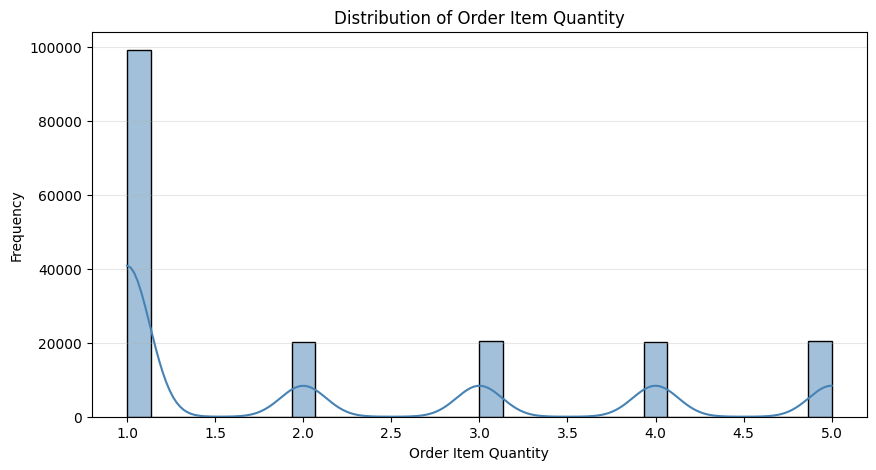

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Order Item Quantity'], bins=30, kde=True,color='steelblue')

plt.title('Distribution of Order Item Quantity')
plt.xlabel('Order Item Quantity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

Observation

The majority of customers purchase only one item per order, while orders containing two or more items occur much less frequently.

Business Insight

Customers predominantly place single-item orders, indicating opportunities to increase the average order size through bundle offers, cross-selling, or quantity-based promotions.

# Order Item Product Price Distribution:

Analyze the distribution of individual product prices within customer orders to understand pricing patterns.

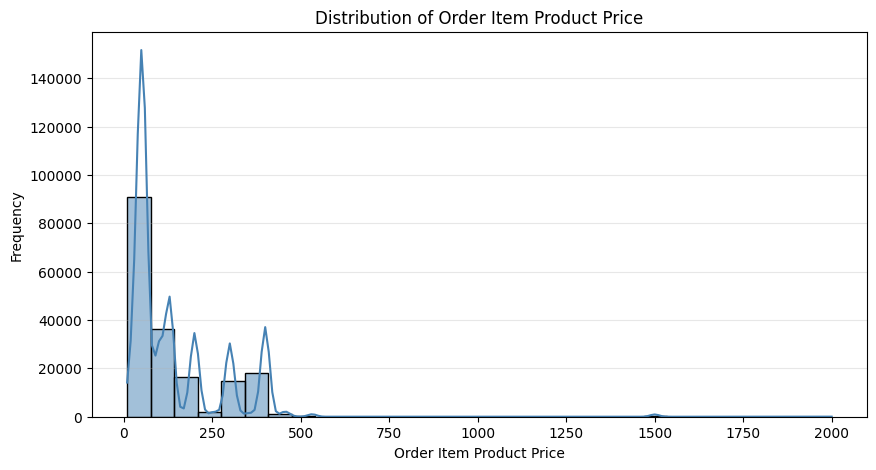

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Order Item Product Price'], bins=30, kde=True,color='steelblue')

plt.title('Distribution of Order Item Product Price')
plt.xlabel('Order Item Product Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

Observation

Similar to the overall product price distribution, most ordered products are priced below $500, with only a few premium-priced products contributing to the upper end of the distribution.

Business Insight

Customer purchases are concentrated around affordable products, while premium-priced items contribute to higher-value transactions and may represent niche or high-margin product segments.

# Order Item Total Distribution:

Analyze the total value of individual order items to understand transaction value distribution and identify high-value purchases.

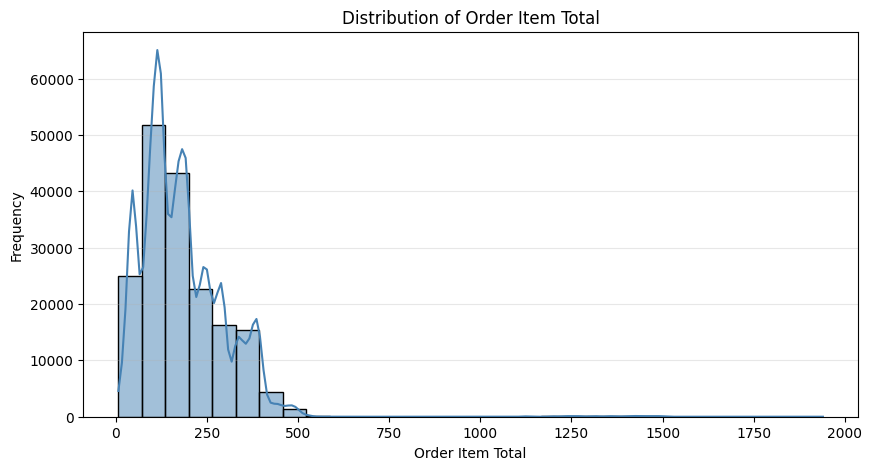

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Order Item Total'], bins=30, kde=True,color='steelblue')

plt.title('Distribution of Order Item Total')
plt.xlabel('Order Item Total')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

Observation

Most order item totals are concentrated at lower values, while a relatively small number of transactions generate significantly higher totals, resulting in a positively skewed distribution.

Business Insight

The business is driven by a high volume of low-to-medium value transactions, whereas a limited number of high-value purchases contribute substantially to overall revenue. These high-value transactions should be retained for further analysis as they represent genuine business activity.

# Days for Shipping (Real):

Analyze the distribution of actual shipping days to understand delivery timelines, identify the most common shipping duration, and evaluate the overall efficiency of the shipping process.

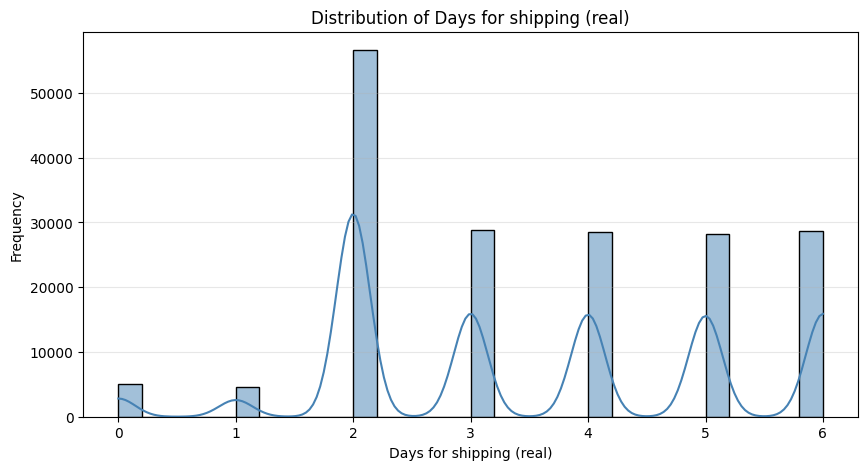

In [ ]:

plt.figure(figsize=(10,5))
sns.histplot(df['Days for shipping (real)'], bins=30, kde=True,color='steelblue')

plt.title('Distribution of Days for shipping (real)')
plt.xlabel('Days for shipping (real)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

Observation

Most orders are delivered within 2 days, making it the most frequent shipping duration. Shipping times ranging from 3 to 6 days occur less frequently, while deliveries completed in 0 or 1 day are relatively rare. Overall, the shipping duration is concentrated between 2 and 6 days, indicating a consistent delivery process.

Business Insight

The majority of orders are fulfilled within a short delivery window, suggesting an efficient logistics network. However, orders requiring 5–6 days for delivery should be further analyzed to identify factors such as shipping mode, destination, or operational delays that may impact customer satisfaction.

In [ ]:
cat_cols

['Type',
 'Delivery Status',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer FullName',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Department Name',
 'Market',
 'Order City',
 'Order Country',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Name',
 'Shipping Mode']

# Type:

Analyze the distribution of transaction types to understand the most commonly used payment methods across customer orders.

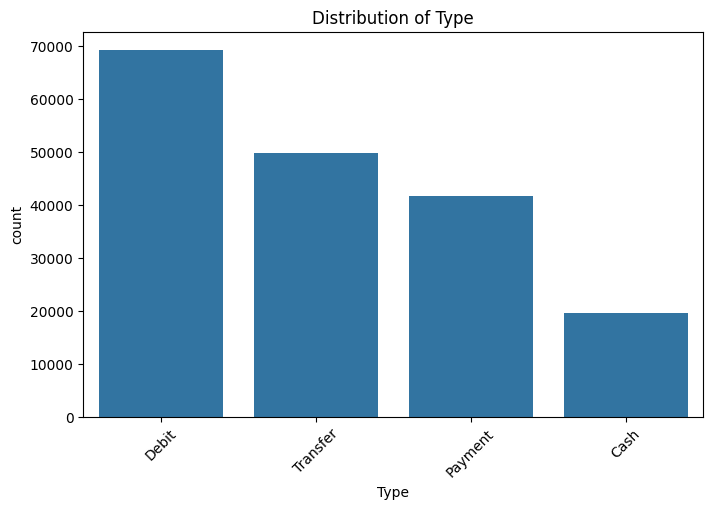

In [ ]:

plt.figure(figsize=(8,5))

sns.countplot(
    data=df1,
    x='Type',
    order=df1['Type'].value_counts().index
)

plt.title('Distribution of Type')
plt.xticks(rotation=45)
plt.show()

Observation

Debit transactions account for the highest number of orders, followed by Transfer and Payment, while Cash transactions represent the smallest share.

Business Insight

Customers predominantly prefer electronic payment methods over cash transactions, indicating a strong adoption of digital payment systems. This can help the business prioritize secure and efficient electronic payment processing.

# Delivery Status:

Examine the distribution of delivery statuses to evaluate overall order fulfillment performance.

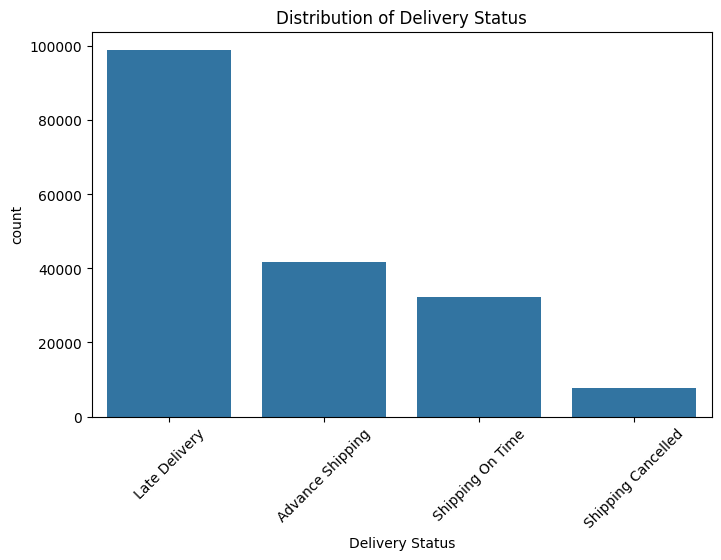

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df1,
    x='Delivery Status',
    order=df1['Delivery Status'].value_counts().index
)

plt.title('Distribution of Delivery Status')
plt.xticks(rotation=45)
plt.show()

Observation

Late Delivery is the most common delivery outcome, followed by Advance Shipping and Shipping On Time, while Shipping Canceled represents only a small proportion of total orders.

Business Insight

A significant number of orders experience delivery delays, suggesting opportunities to improve logistics planning and supply chain efficiency to enhance customer satisfaction.

# Category Name:

Analyze the distribution of product categories to identify the most frequently ordered product groups.

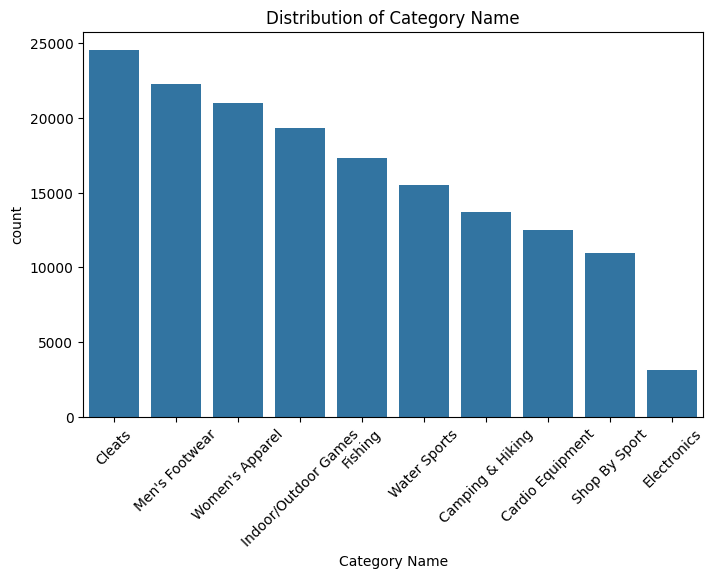

In [ ]:

plt.figure(figsize=(8,5))

sns.countplot(
    data=df1,
    x='Category Name',
    order=df1['Category Name'].value_counts().head(10).index
)

plt.title('Distribution of Category Name')
plt.xticks(rotation=45)
plt.show()

Observation

Cleats, Men's Footwear, and Women's Apparel are the most frequently purchased product categories, whereas Electronics records the lowest number of orders.

Business Insight

Customer demand is concentrated in sports apparel and footwear categories, indicating that inventory planning and marketing efforts should prioritize these high-demand product segments.

# Department Name:

Examine the distribution of departments to understand which business divisions contribute the highest number of transactions.

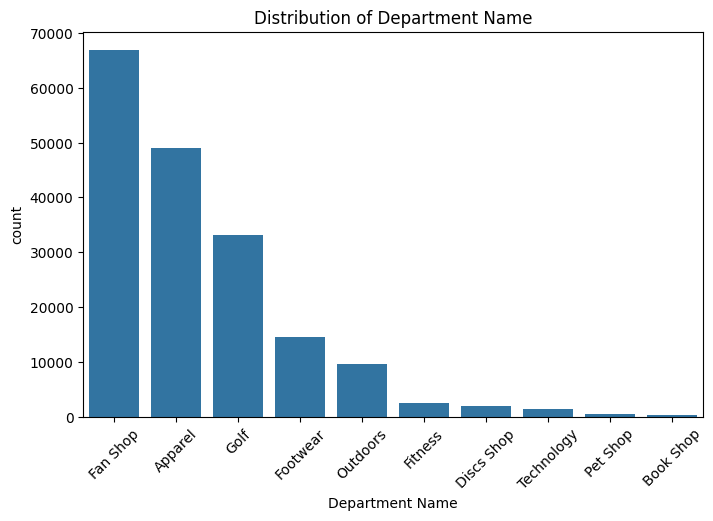

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df1,
    x='Department Name',
    order=df1['Department Name'].value_counts().head(10).index
)

plt.title('Distribution of Department Name',)
plt.xticks(rotation=45)
plt.show()


Observation

Fan Shop generates the highest number of orders, followed by Apparel and Golf, while departments such as Pet Shop and Book Shop contribute only a very small number of transactions.

Business Insight

The majority of business activity is concentrated within a few departments. Low-performing departments should be evaluated for product assortment, marketing effectiveness, or inventory optimization.

# Customer Segment:

Analyze customer segments to understand the composition of the company's customer base.


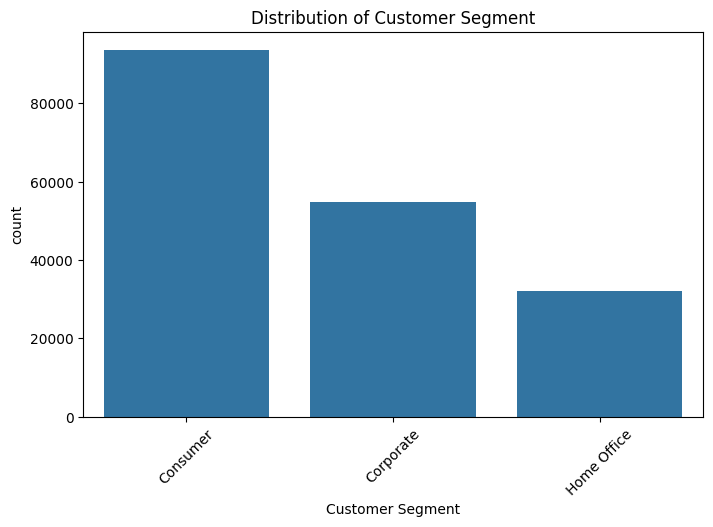

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df1,
    x='Customer Segment',
    order=df1['Customer Segment'].value_counts().index
)

plt.title('Distribution of Customer Segment')
plt.xticks(rotation=45)
plt.show()

Observation

The Consumer segment accounts for the largest share of customers, followed by Corporate and Home Office.

Business Insight

Consumer customers represent the primary revenue-driving segment. Marketing campaigns and customer retention strategies should continue focusing on this segment while identifying opportunities to grow Corporate and Home Office customers.

# Market:

Analyze the distribution of orders across different global markets.

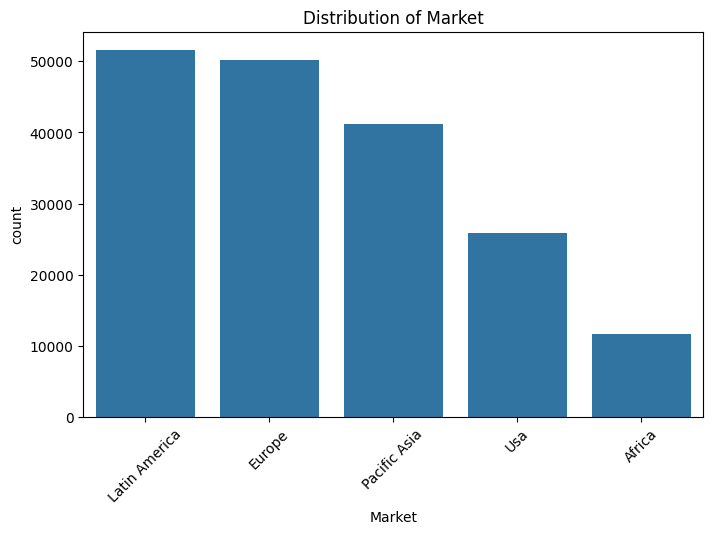

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Market',
    order=df1['Market'].value_counts().index
)

plt.title('Distribution of Market')
plt.xticks(rotation=45)
plt.show()

Observation

Latin America and Europe account for the highest number of orders, whereas Africa contributes the lowest transaction volume.

Business Insight

The business has a strong presence in Latin America and Europe. Markets with lower order volumes may represent opportunities for future expansion and targeted business development.

# Order Region:

Examine the distribution of customer orders across geographical regions.

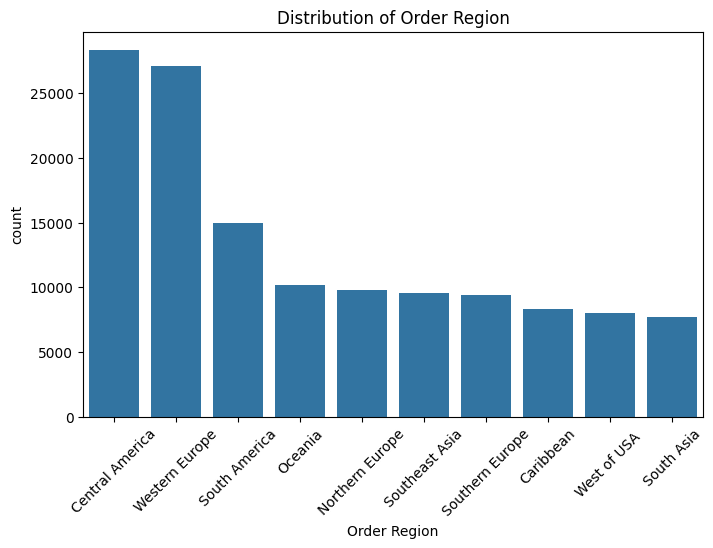

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df1,
    x='Order Region',
    order=df1['Order Region'].value_counts().head(10).index
)

plt.title('Distribution of Order Region')
plt.xticks(rotation=45)
plt.show()

Observation

Central America and Western Europe record the highest order volumes, while the remaining regions contribute comparatively fewer orders.

Business Insight

Customer demand is concentrated in a few major regions, indicating where inventory, logistics resources, and marketing investments should be prioritized to maximize operational efficiency.

# Order Status:

Analyze the distribution of order statuses to evaluate the overall order processing lifecycle.

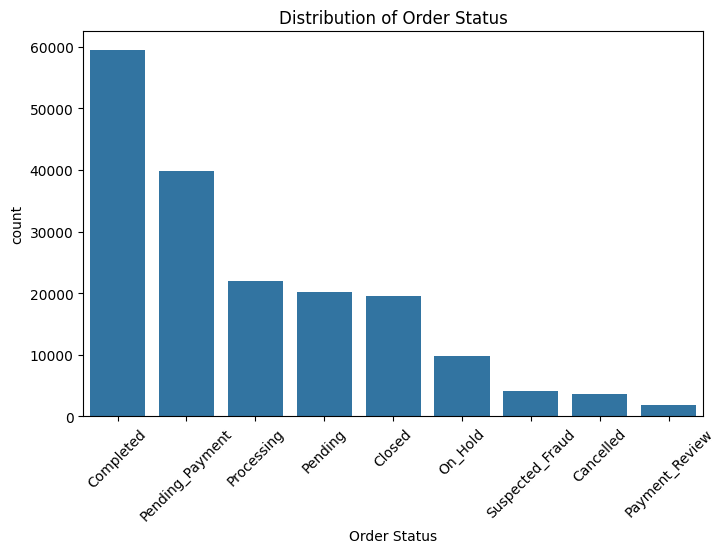

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df1,
    x='Order Status',
    order=df1['Order Status'].value_counts().index
)

plt.title('Distribution of Order Status')
plt.xticks(rotation=45)
plt.show()

Observation

Completed orders represent the largest proportion of transactions, followed by Pending Payment and Processing, while Canceled, Suspected Fraud, and Payment Review occur relatively infrequently.

Business Insight

The high proportion of completed orders indicates an effective order management process. However, pending and processing orders should be monitored to reduce fulfillment delays, while fraud-related cases require continued risk management.

# Shipping Mode:

Analyze the distribution of shipping modes to understand customer shipping preferences.

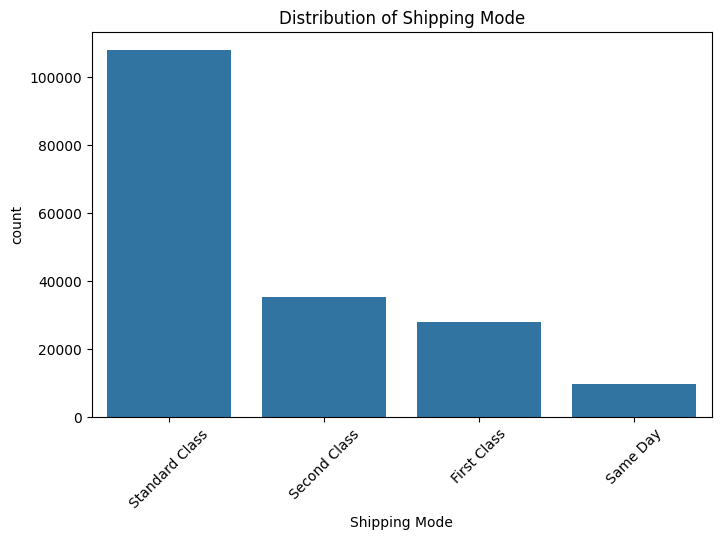

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df1,
    x='Shipping Mode',
    order=df1['Shipping Mode'].value_counts().index
)

plt.title('Distribution of Shipping Mode')
plt.xticks(rotation=45)
plt.show()

Observation

Standard Class is the most frequently selected shipping mode, followed by Second Class and First Class, while Same Day delivery is the least preferred option.

Business Insight

Customers primarily prefer cost-effective shipping options over premium delivery services. Optimizing Standard Class logistics can have the greatest impact on operational efficiency and customer satisfaction.

# Bivariate Analysis

# 1. Category Name vs Sales (Bar Plot)
Objective

Compare total sales across different product categories to identify the highest revenue-generating categories.

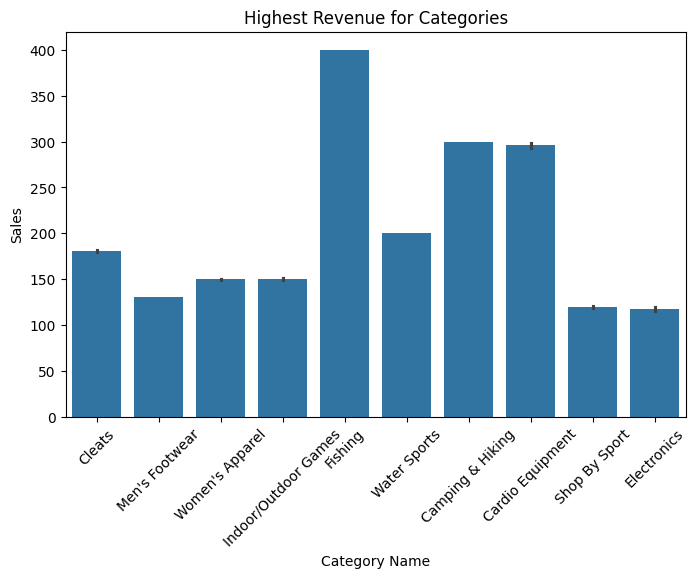

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df1,
    x='Category Name',
    y='Sales',
    order=df1['Category Name'].value_counts().head(10).index
)

plt.title('Highest Revenue for Categories')
plt.xticks(rotation=45)
plt.show()

Observation

Indoor/Outdoor Games records the highest average sales, followed by Camping & Hiking and Cardio Equipment. Electronics and Shop By Sport generate the lowest average sales.

Business Insight

High-performing categories should receive priority in inventory planning, promotions, and marketing campaigns, while lower-performing categories may require pricing, assortment, or promotional improvements to increase demand.

# 2. Department Name vs Order Profit Per Order (Bar Plot)
Objective

Analyze the average profit generated by each department to identify the most profitable business units.

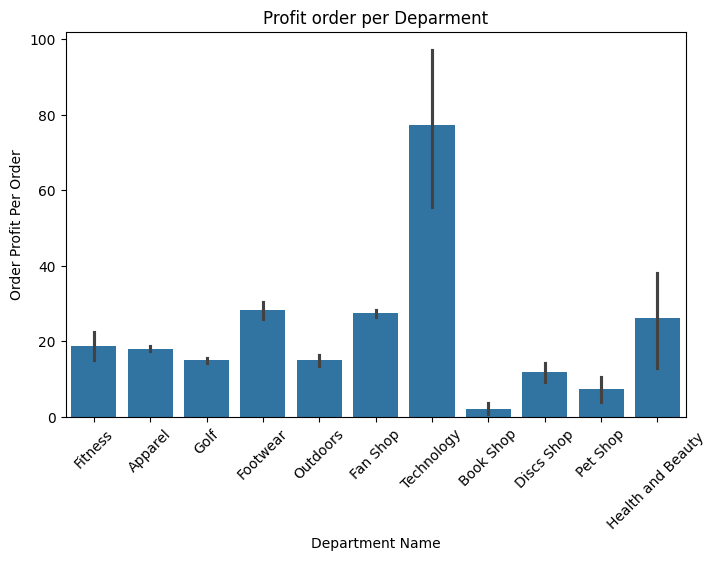

In [ ]:


plt.figure(figsize=(8,5))

sns.barplot(
    data=df1,
    x='Department Name',
    y='Order Profit Per Order'
)

plt.title('Profit order per Deparment')
plt.xticks(rotation=45)
plt.show()

Observation

The Technology department generates the highest average profit per order, whereas the Book Shop department contributes the lowest profit.

Business Insight

High-profit departments represent valuable revenue drivers and should be supported through inventory and marketing investments. Lower-profit departments should be reviewed to identify opportunities for improving pricing, product mix, or operational efficiency.

# 3. Market vs Sales (Bar Plot)
Objective

Compare average sales across different markets to evaluate regional business performance.

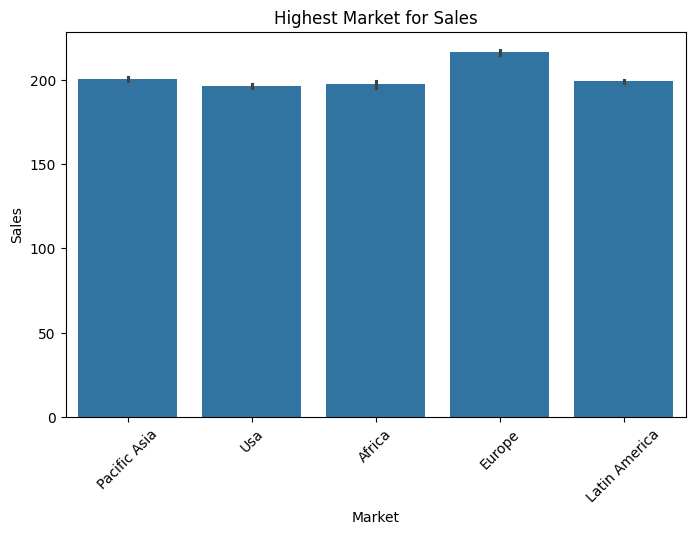

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df1,
    x='Market',
    y='Sales'
)

plt.title('Highest Market for Sales')
plt.xticks(rotation=45)
plt.show()

Observation

Europe records the highest average sales, while the remaining markets exhibit relatively similar sales performance with only minor differences.

Business Insight

Europe represents the strongest-performing market and should remain a strategic focus. Markets with lower sales may offer opportunities for expansion through localized marketing and customer engagement initiatives.

# 4. Customer Segment vs Sales (Box Plot)
Objective

Examine the distribution of sales across customer segments to understand purchasing behavior and transaction variability.

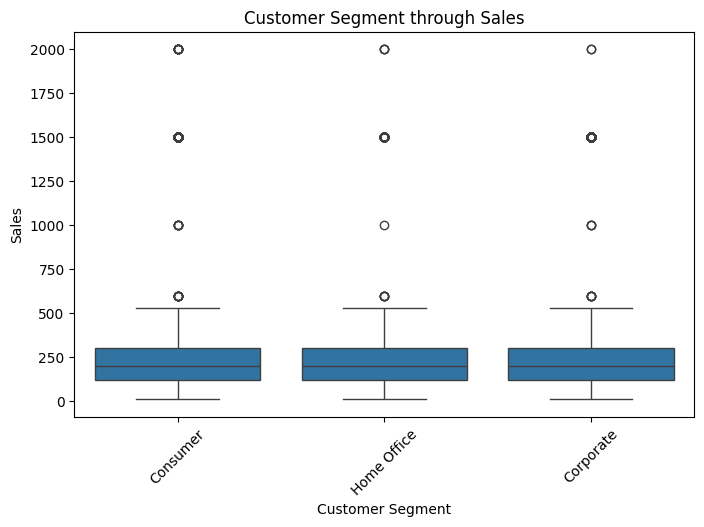

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df1,
    x='Customer Segment',
    y='Sales'
)

plt.title('Customer Segment through Sales')
plt.xticks(rotation=45)
plt.show()

Observation

Sales distributions are broadly similar across Consumer, Corporate, and Home Office segments. All segments contain several high-value orders, indicating the presence of premium customer transactions.

Business Insight

No single customer segment consistently outperforms the others in terms of order value. Therefore, customer retention and marketing strategies should be developed for all segments while identifying high-value customers within each group.

# 5. Monthly Profit Trend (Line Plot)
Objective

Analyze monthly profit trends over time to identify growth patterns, seasonal fluctuations, and periods of significant change.

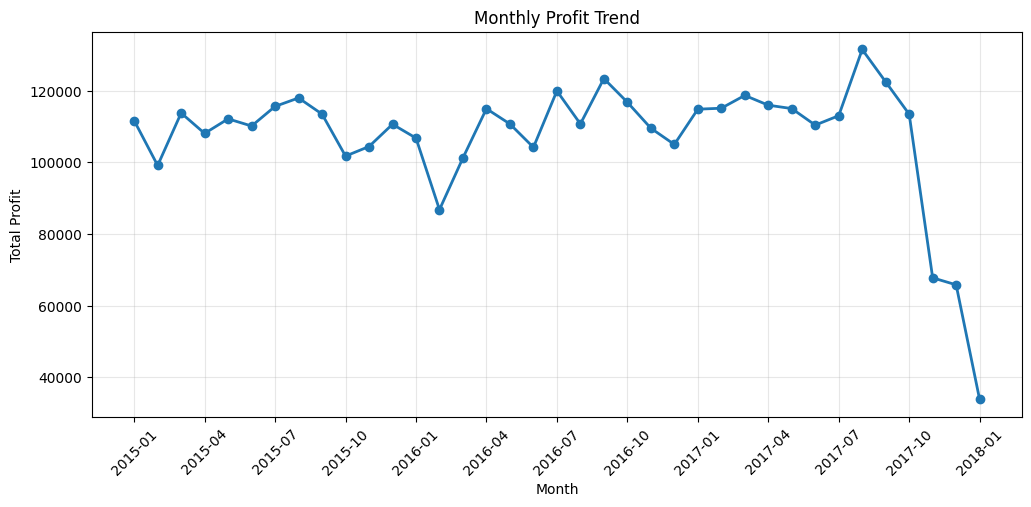

In [ ]:
monthly_profit = (
    df1.groupby(df1['Order_Date'].dt.to_period('M'))['Order Profit Per Order']
      .sum()
)

plt.figure(figsize=(12,5))

plt.plot(monthly_profit.index.astype(str),
         monthly_profit.values,
         marker='o',
         linewidth=2)

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Total Profit')

plt.xticks(ticks=range(0, len(monthly_profit.index), 3),
           labels=monthly_profit.index.astype(str)[::3],
           rotation=45)

plt.grid(alpha=0.3)

plt.show()

Observation

Profit remains relatively stable throughout most of the analysis period, with moderate fluctuations. A noticeable decline appears in the final months of the dataset.

Business Insight

The business maintains consistent profitability across most months. The sharp decline observed at the end of the timeline should be validated to determine whether it reflects incomplete data for the final reporting period or an actual decrease in business performance.

# 6. Product Price vs Sales (Scatter Plot)
Objective

Examine the relationship between product price and sales to determine whether higher-priced products generate higher sales values.

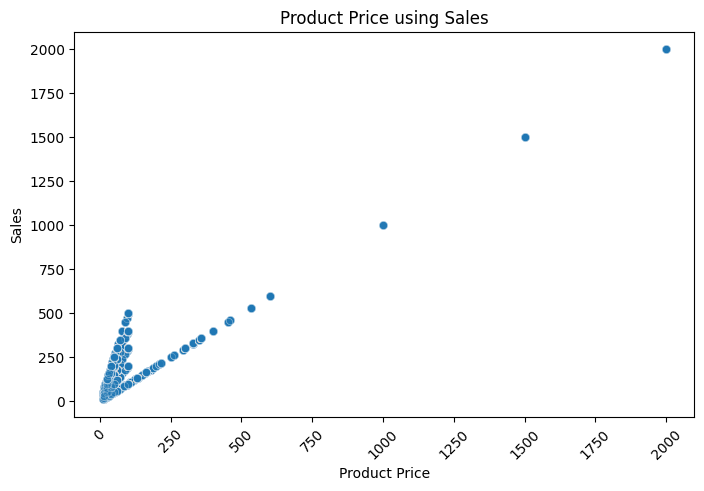

In [ ]:

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df1,
    x='Product Price',
    y='Sales',alpha=0.3
)

plt.title('Product Price using Sales')
plt.xticks(rotation=45)
plt.show()

Observation

A positive relationship is observed between product price and sales, with higher-priced products generally associated with higher sales values. However, most transactions occur at lower price ranges.

Business Insight

Premium-priced products contribute to high-value sales, while lower-priced products drive transaction volume. Maintaining a balanced product portfolio can help maximize both revenue and customer reach.

# 7. Shipping Mode vs Delivery Status (Countplot)
Objective

Analyze delivery outcomes across different shipping modes to evaluate logistics performance.

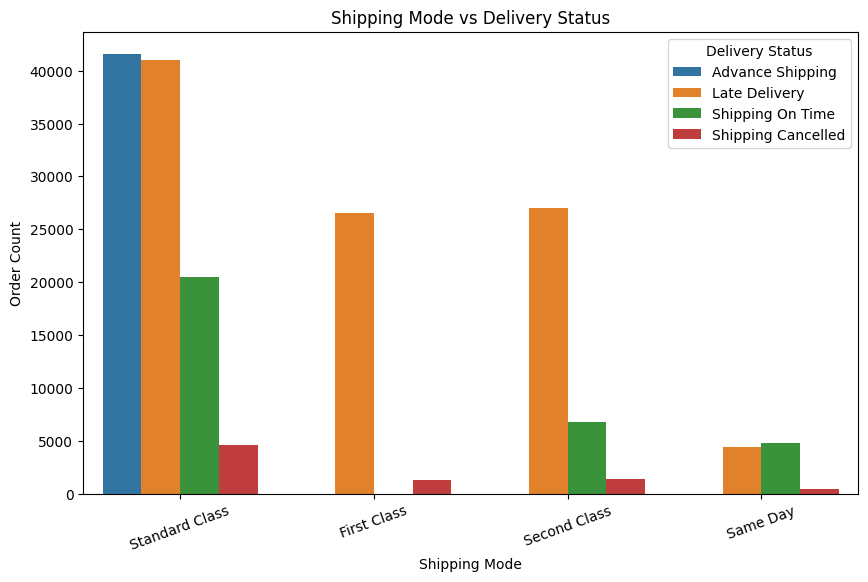

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df1,
    x='Shipping Mode',
    hue='Delivery Status'
)

plt.title('Shipping Mode vs Delivery Status')
plt.xlabel('Shipping Mode')
plt.ylabel('Order Count')
plt.xticks(rotation=20)

plt.legend(title='Delivery Status')
plt.show()

Observation

Standard Class handles the largest number of shipments and also records the highest number of late deliveries due to its larger shipment volume. Same Day shipping has comparatively fewer orders and fewer delivery issues.

Business Insight

Standard Class represents the company's primary shipping method and should be the main focus for improving delivery efficiency. Optimizing this shipping mode can significantly enhance overall customer satisfaction.

# 8. Shipping Mode vs Actual Shipping Days (Box Plot)
Objective

Compare actual shipping durations across different shipping modes to evaluate delivery efficiency.

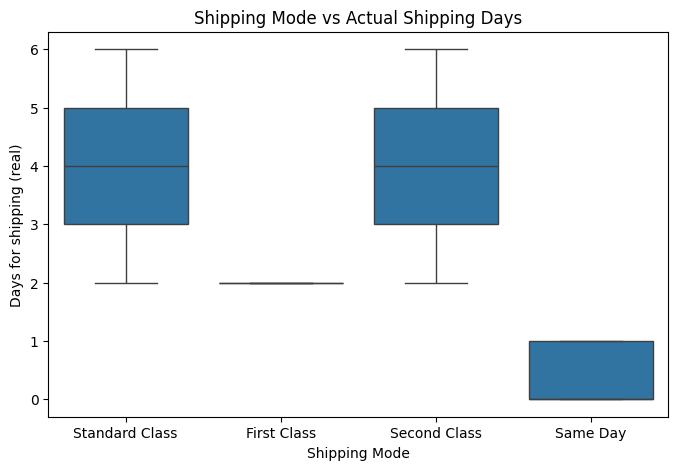

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df1,
    x='Shipping Mode',
    y='Days for shipping (real)'
)

plt.title('Shipping Mode vs Actual Shipping Days')
plt.show()

Observation

Same Day shipping has the shortest delivery time, while First Class consistently delivers within approximately two days. Standard Class and Second Class exhibit greater variability in shipping duration.

Business Insight

Premium shipping services provide faster and more predictable delivery performance. Standard and Second Class shipping may require operational improvements to reduce delivery variability and improve customer experience.

# 9. Discount vs Order Profit Per Order (Regression Plot)
Objective

Analyze the relationship between discounts and order profitability to understand the impact of discounting strategies.

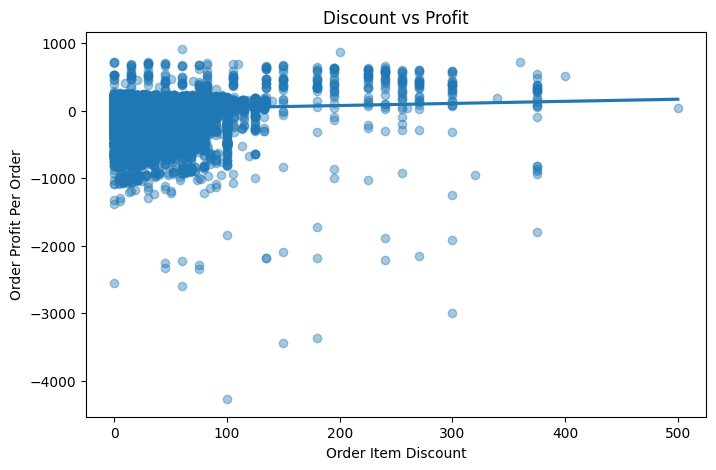

In [ ]:


plt.figure(figsize=(8,5))

sns.regplot(
    data=df1,
    x='Order Item Discount',
    y='Order Profit Per Order',
    scatter_kws={'alpha':0.4}
)

plt.title('Discount vs Profit')
plt.show()

Observation

Most orders receive relatively small discounts, and the relationship between discount and profit appears weak. Several orders with large financial losses are visible across different discount levels.

Business Insight

Discounts alone do not determine profitability. Other business factors, including product pricing, shipping costs, and operational expenses, likely have a significant impact on order profit. Loss-making orders should be investigated individually.

# 10. Delivery Status vs Order Profit Per Order (Box Plot)
Objective

Compare profit distributions across different delivery outcomes to determine whether delivery performance influences profitability.

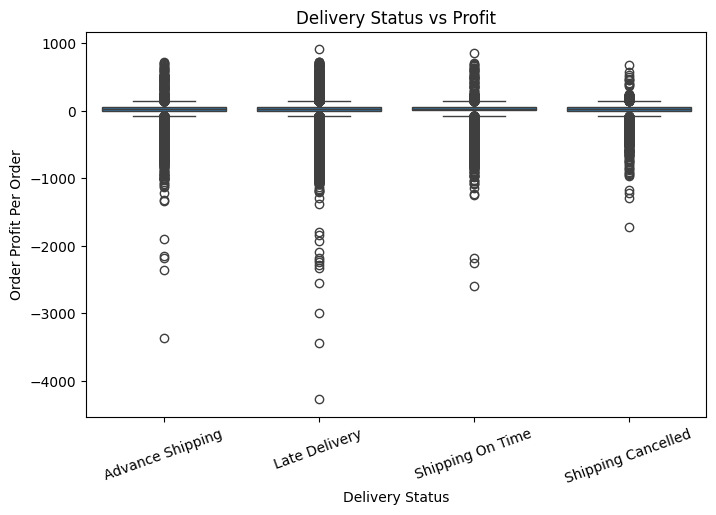

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df1,
    x='Delivery Status',
    y='Order Profit Per Order'
)

plt.xticks(rotation=20)
plt.title('Delivery Status vs Profit')
plt.show()

Observation

Profit distributions are broadly similar across all delivery statuses, although Late Delivery exhibits a wider spread of profit values and includes several large losses.

Business Insight

Delivery performance alone does not appear to be the primary factor affecting profitability. However, reducing late deliveries may help minimize operational inefficiencies and prevent extreme financial losses in certain orders.

# Correlation Analysis
Objective

Analyze the relationships among numerical variables using a correlation matrix to identify strong positive or negative associations that may influence sales, profitability, pricing, discounts, and logistics performance.

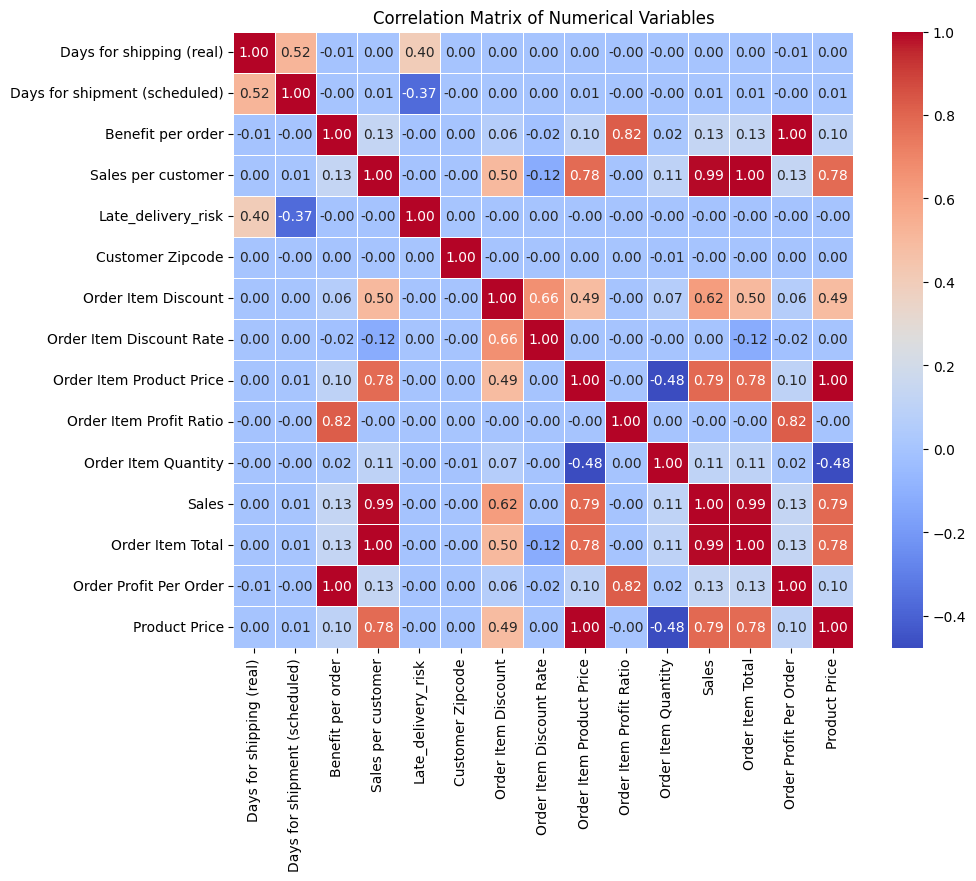

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',
    linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')

plt.show()

Observation

* Sales has a very strong positive correlation with Sales per Customer (0.99) and
Order Item Total (0.99), indicating that higher order values directly contribute to increased sales.
* Product Price shows a strong positive correlation with Sales (0.79), suggesting that premium-priced products contribute significantly to revenue.
* Benefit per Order has a strong positive relationship with Order Profit Ratio (0.82) and Order Profit Per Order (1.00), reflecting consistent profitability metrics.
* Order Item Discount has a moderate positive correlation with Sales (0.62), indicating that discounts can encourage higher sales volumes.
* Days for Shipping (Real) has a moderate positive correlation with Late Delivery Risk (0.40), showing that longer shipping times increase the likelihood of delayed deliveries.
* Product Price has a moderate negative correlation with Order Item Quantity (-0.48), suggesting that higher-priced products are generally purchased in smaller quantities.
* Most remaining variables exhibit weak or negligible correlations, indicating that business performance depends on multiple operational factors rather than a single metric.


Business Insight


The correlation analysis indicates that sales are primarily driven by product pricing and order value, while profitability is closely linked to profit-related metrics. Discounts contribute to increased sales but should be carefully managed to maintain profitability. Additionally, reducing shipping time can help minimize delivery delays and improve overall customer satisfaction.

# Outlier Analysis
Objective

Identify potential outliers across all numerical variables to determine whether extreme observations represent genuine business transactions or possible data anomalies.

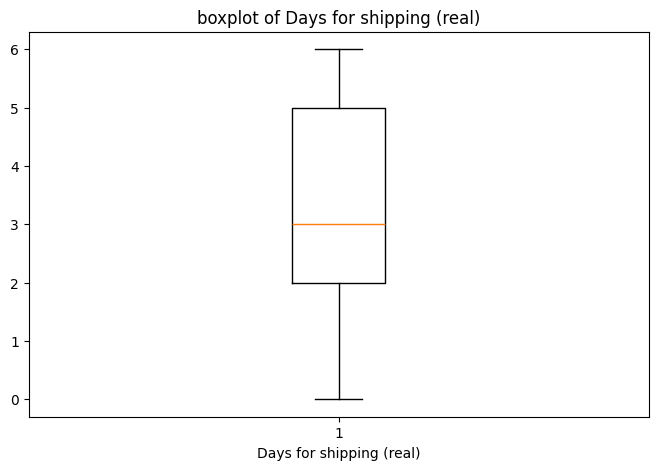

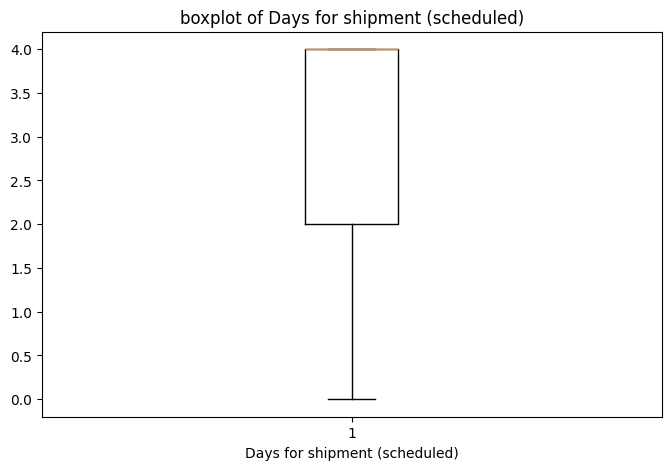

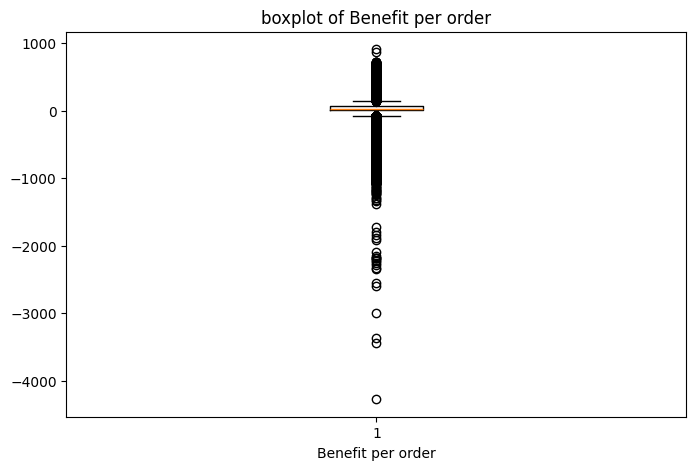

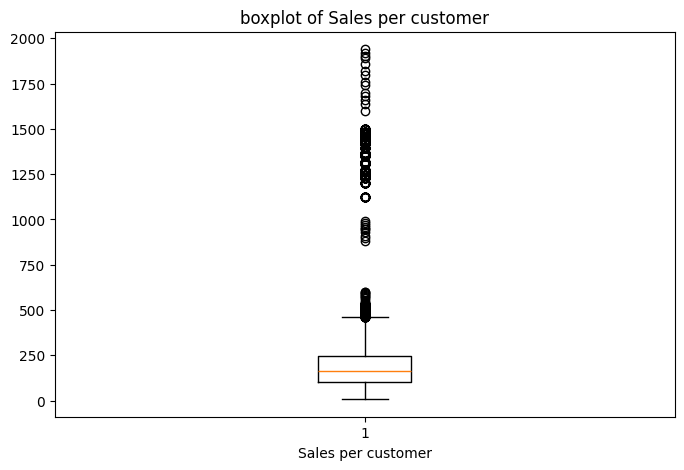

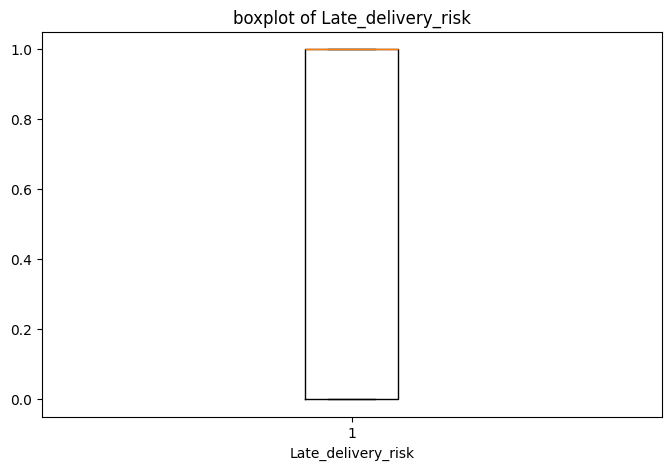

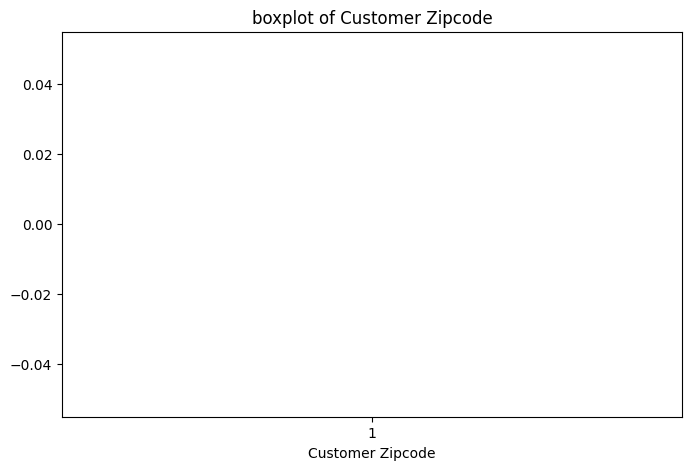

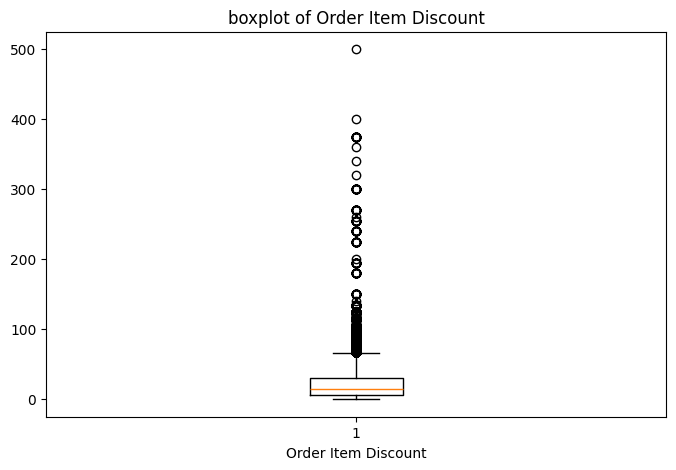

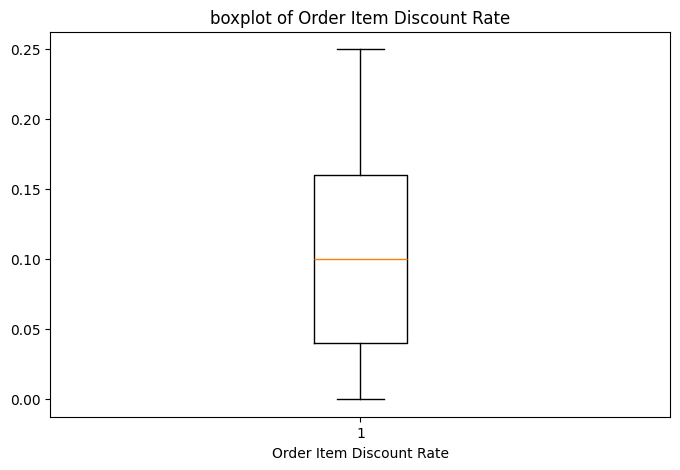

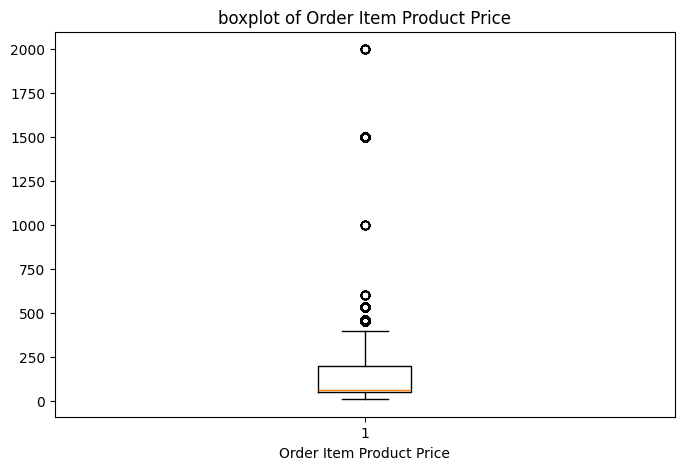

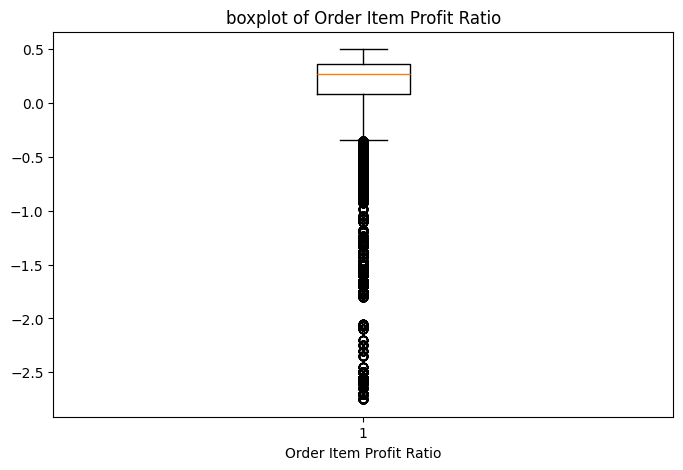

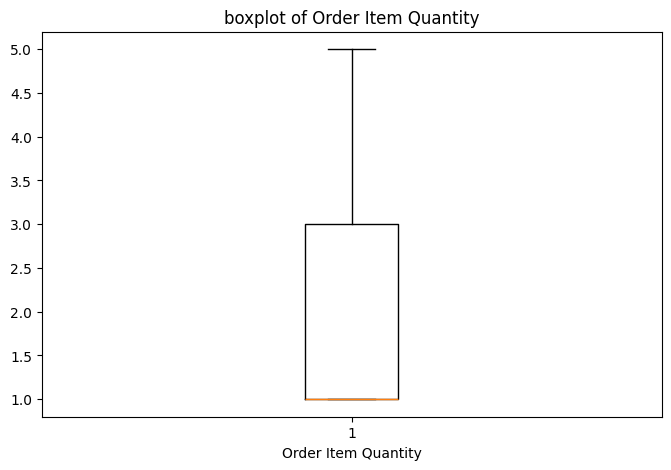

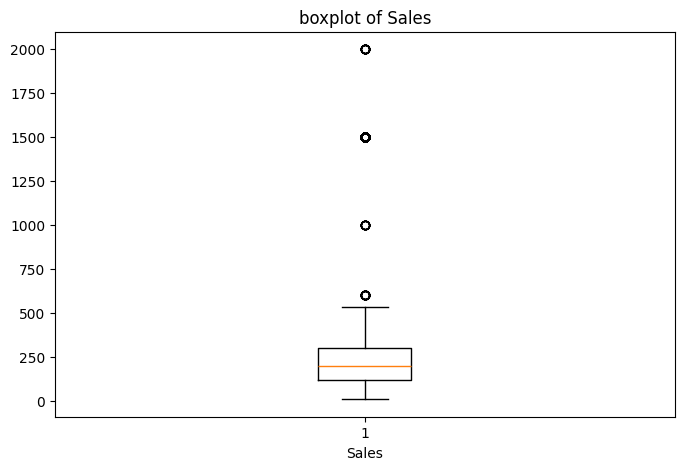

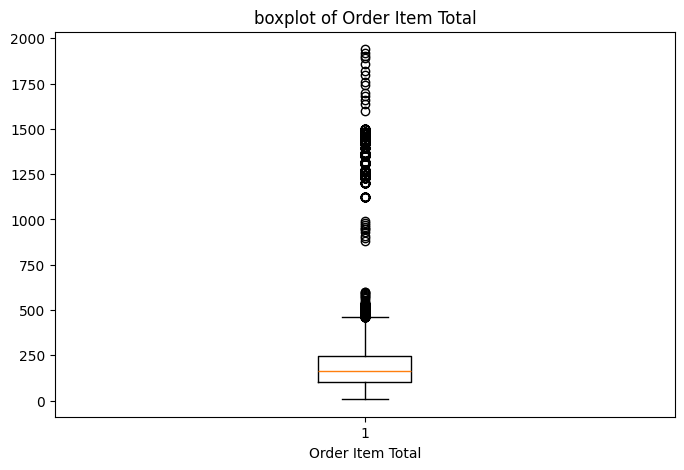

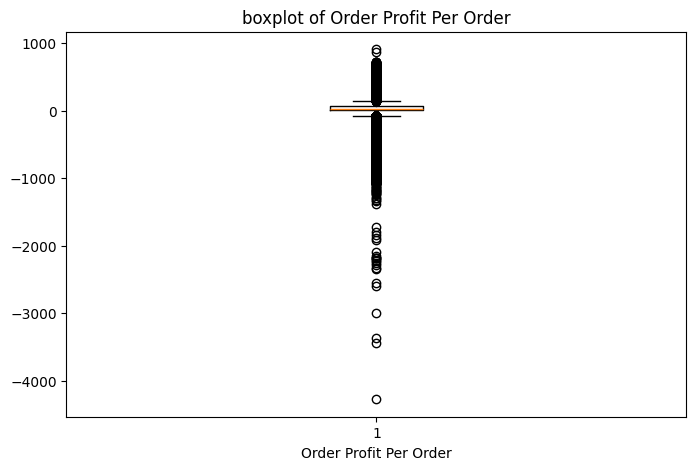

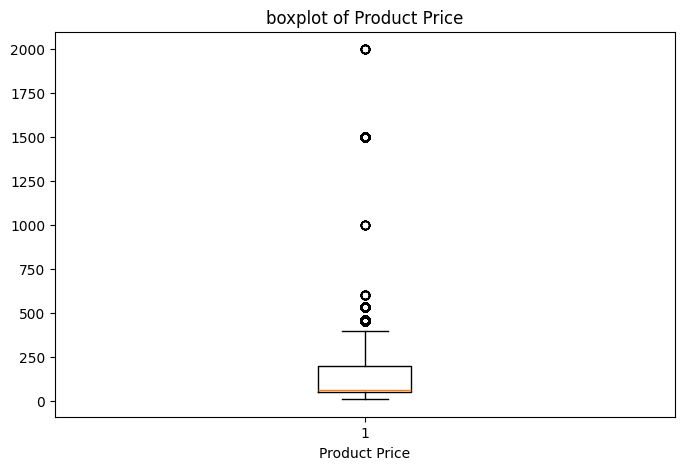

In [ ]:
for i in num_cols:
  plt.figure(figsize=(8,5))
  plt.boxplot(df1[i])
  plt.title(f'boxplot of {i}')
  plt.xlabel(i)
  plt.show()

Observation
* Days for Shipping (Real) and Days for Shipment (Scheduled) do not contain significant outliers, indicating consistent shipping durations.
* Benefit per Order and Order Profit Per Order contain both high-profit and large-loss outliers, reflecting highly profitable and loss-making transactions.
* Sales per Customer, Sales, and Order Item Total contain several high-value outliers, representing large customer purchases.
* Order Item Discount contains a small number of unusually high discounts compared to most transactions.
* Order Item Product Price and Product Price contain premium-priced products that appear as high-value outliers.
* Order Item Profit Ratio includes several negative outliers, indicating orders with exceptionally low profit margins or financial losses.
* Order Item Quantity, Order Item Discount Rate, Late Delivery Risk, and Customer Zipcode do not exhibit meaningful outliers due to their limited value ranges or categorical/binary nature.

Business Insight

Most detected outliers represent legitimate business scenarios such as premium-priced products, bulk customer purchases, promotional discounts, and exceptionally profitable or loss-making orders. These values provide valuable business insights rather than indicating data quality issues.


Decision

No outliers were removed because the identified extreme values correspond to valid business transactions. Retaining these observations ensures that the analysis accurately reflects real-world customer purchasing behavior, pricing strategies, and business performance.

# Feature Engineering

Objective

Create new business-relevant features from the existing data to enhance analysis, improve reporting, and support SQL queries and Power BI dashboards.

In [ ]:
df1['Order_Date'] = df1['Order_Date'].dt.normalize()
df1['Shipping_Date'] = df1['Shipping_Date'].dt.normalize()

## Order Year

In [ ]:
df1['Order_Year']=df1['Order_Date'].dt.year

## Month Number

In [ ]:
df1['Order_Month_Number']=df1['Order_Date'].dt.month

## Month Name

In [ ]:
df1['Order Month_Name']=df1['Order_Date'].dt.month_name()

## Quarter

In [ ]:
df1['Order Quarter']=df1['Order_Date'].dt.quarter

## Day

In [ ]:
df1['Order Day']=df1['Order_Date'].dt.day



## Week Day

In [ ]:
df1['Order Week_Day']=df1['Order_Date'].dt.day_name()

## Shipping Delay

In [ ]:
df1['Shipping_Delay']=df1['Days for shipping (real)']-df1['Days for shipment (scheduled)']

In [ ]:
df1['Shipping_Performance']=df1['Shipping_Delay'].apply(
    lambda x:'Delayed' if x> 0 else 'On Time/Early'
)

## Shipping Year

In [ ]:
df1['Shipping_Year']=df1['Shipping_Date'].dt.year

## Shipping Month

In [ ]:
df1['Shipping Month_Name']=df1['Shipping_Date'].dt.month_name()

## Shipping Month Number

In [ ]:
df1["Shipping Month_Number"]=df1['Shipping_Date'].dt.month

## Profit Category

In [ ]:
def profit_category(profit):
    if profit < 0:
        return 'Loss'
    elif profit < 100:
        return 'Low Profit'
    elif profit < 500:
        return 'Medium Profit'
    else:
        return 'High Profit'

df1['Profit Category'] = df1['Order Profit Per Order'].apply(profit_category)

## Price Category

In [ ]:
df1['Price_Category']=pd.cut(
    df1['Product Price'],
    bins=[0,100,500,1000,float('inf')],
    labels=['Low','Medium','High','Premium']
)


## Discount Category

In [ ]:
df['Discount Category'] = pd.cut(
    df['Order Item Discount'],
    bins=[-0.01,10,30,60,float('inf')],
    labels=['Low','Medium','High','Very High']
)

Objective

Create new business-oriented features from existing variables to improve analytical capabilities, support business reporting, and enhance SQL and Power BI analysis.

Business Insight

The engineered features enable deeper analysis of sales trends, logistics performance, profitability, pricing strategies, and customer purchasing patterns. These features provide additional business context that is not directly available in the raw dataset and will be used throughout the SQL analysis and Power BI dashboard.

In [ ]:
df1.rename(columns={
    'Days for shipping (real)': 'Days_For_Shipping_Real',
    'Days for shipment (scheduled)': 'Days_For_Shipment_Scheduled',
    'Benefit per order': 'Benefit_Per_Order',
    'Sales per customer': 'Sales_Per_Customer',
    'Delivery Status': 'Delivery_Status',
    'Category Id': 'Category_ID',
    'Category Name': 'Category_Name',
    'Customer City': 'Customer_City',
    'Customer Country': 'Customer_Country',
    'Customer Id': 'Customer_ID',
    'Customer FullName': 'Customer_Full_Name',
    'Customer Segment': 'Customer_Segment',
    'Customer State': 'Customer_State',
    'Customer Street': 'Customer_Street',
    'Customer Zipcode': 'Customer_Zipcode',
    'Department Id': 'Department_ID',
    'Department Name': 'Department_Name',
    'Order City': 'Order_City',
    'Order Country': 'Order_Country',
    'Order Id': 'Order_ID',
    'Order Item Discount': 'Order_Item_Discount',
    'Order Item Discount Rate': 'Order_Item_Discount_Rate',
    'Order Item Id': 'Order_Item_ID',
    'Order Item Product Price': 'Order_Item_Product_Price',
    'Order Item Profit Ratio': 'Order_Item_Profit_Ratio',
    'Order Item Quantity': 'Order_Item_Quantity',
    'Order Item Total': 'Order_Item_Total',
    'Order Profit Per Order': 'Order_Profit_Per_Order',
    'Order Region': 'Order_Region',
    'Order State': 'Order_State',
    'Order Status': 'Order_Status',
    'Product Card Id': 'Product_Card_ID',
    'Product Name': 'Product_Name',
    'Product Price': 'Product_Price',
    'Shipping Mode': 'Shipping_Mode',
    'Order Month_Name': 'Order_Month_Name',
    'Order Quarter': 'Order_Quarter',
    'Order Day': 'Order_Day',
    'Order Week_Day': 'Order_Week_Day',
    'Shipping Month_Name': 'Shipping_Month_Name',
    'Shipping Month_Number': 'Shipping_Month_Number',
    'Profit Category': 'Profit_Category'
}, inplace=True)

## Renamed columns to SQL-friendly names for improved readability and easier querying.

In [ ]:
df1.to_csv('Supply_Chain_New.csv',index=False,lineterminator="\r\n")


In [ ]:
files.download('Supply_Chain_New.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>